In [1]:
library(Seurat)
library(glue)
library(qs)
library(parallel)
library(ggplot2)
library(stringr)
library(ggsci)
library(reshape2)
library(scales)
library(hues)
library(RColorBrewer)
library(patchwork)
library(ComplexHeatmap)
library(Polychrome)
library(scico)
library(SeuratDisk)
library(ggpointdensity)
library(viridis)
library(dplyr)
library(tidyr)

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘qs’ was built under R version 4.4.2”
qs 0.26.3

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.4.2”
Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap packa

In [2]:
options(future.globals.maxSize = 30e+09)

# Initialize seurat objects

In [3]:
base_dir <- "/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/cellranger_count"

In [4]:
all_experiments <- list.dirs("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/cellranger_count",
                             recursive=FALSE,
                             full.names=FALSE)

In [5]:
all_experiments_with_filtered_feature_bc_matrix <- sapply(all_experiments, function(experiment){
    dir.exists(glue("{base_dir}/{experiment}/outs/filtered_feature_bc_matrix"))
})

In [6]:
all_experiments <- all_experiments[all_experiments_with_filtered_feature_bc_matrix]

In [26]:
all_seurat_objs <- lapply(all_experiments, function(experiment){
    message(glue("Processing experiment {experiment}"))
    obj.tmp <- Read10X(glue("{base_dir}/{experiment}/outs/filtered_feature_bc_matrix/"))
    obj.tmp <- CreateSeuratObject(counts=obj.tmp,
                                  min.cells=0,
                                  min.features=0,
                                  assay="RNA",
                                  project=experiment)
})

Processing experiment 7_F_F_M_M_5prime_gex

Processing experiment 7_F_plus_T_F_M_plus_T_M_5prime_gex

Processing experiment 7_M_plus_F_M_M_plus_F_F_5prime_gex

Processing experiment 7_M_plus_F_plus_T_M_M_plus_F_plus_T_F_5prime_gex

Processing experiment 8_F_F_M_M_5prime_gex

Processing experiment 8_F_plus_T_F_M_plus_T_M_5prime_gex

Processing experiment 8_M_plus_F_M_M_plus_F_F_5prime_gex

Processing experiment 8_M_plus_F_plus_T_M_M_plus_F_plus_T_F_5prime_gex

Processing experiment 9_F_F_M_M_5prime_gex

Processing experiment 9_F_plus_T_F_M_plus_T_M_5prime_gex

Processing experiment 9_M_plus_F_M_M_plus_F_F_5prime_gex

Processing experiment 9_M_plus_F_plus_T_M_M_plus_F_plus_T_F_5prime_gex



# Quality controls

In [8]:
all_seurat_objs <- lapply(all_seurat_objs, function(obj){
    obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern="^MT-")
    obj
})

In [9]:
qc_data <- data.frame(nFeature_RNA=unlist(lapply(all_seurat_objs, function(obj){obj[["nFeature_RNA"]]})),
                      percentMT=unlist(lapply(all_seurat_objs, function(obj){obj[["percent.mt"]]})))

In [10]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 500)
ggplot(qc_data, aes(percentMT, nFeature_RNA, color=after_stat(ndensity))) +
    geom_pointdensity(size=.15,
                      adjust=2.3,
                      method="neighbors") +
    scale_color_viridis() +
    theme_classic() +
    labs(x="% MT",
         y="# Genes detected",
         color="Density") +
    theme(aspect.ratio=1,
          legend.key.size=unit(0.3, 'cm'),
          legend.title=element_text(size=6),
          legend.text=element_text(size=6)) -> qc_plot

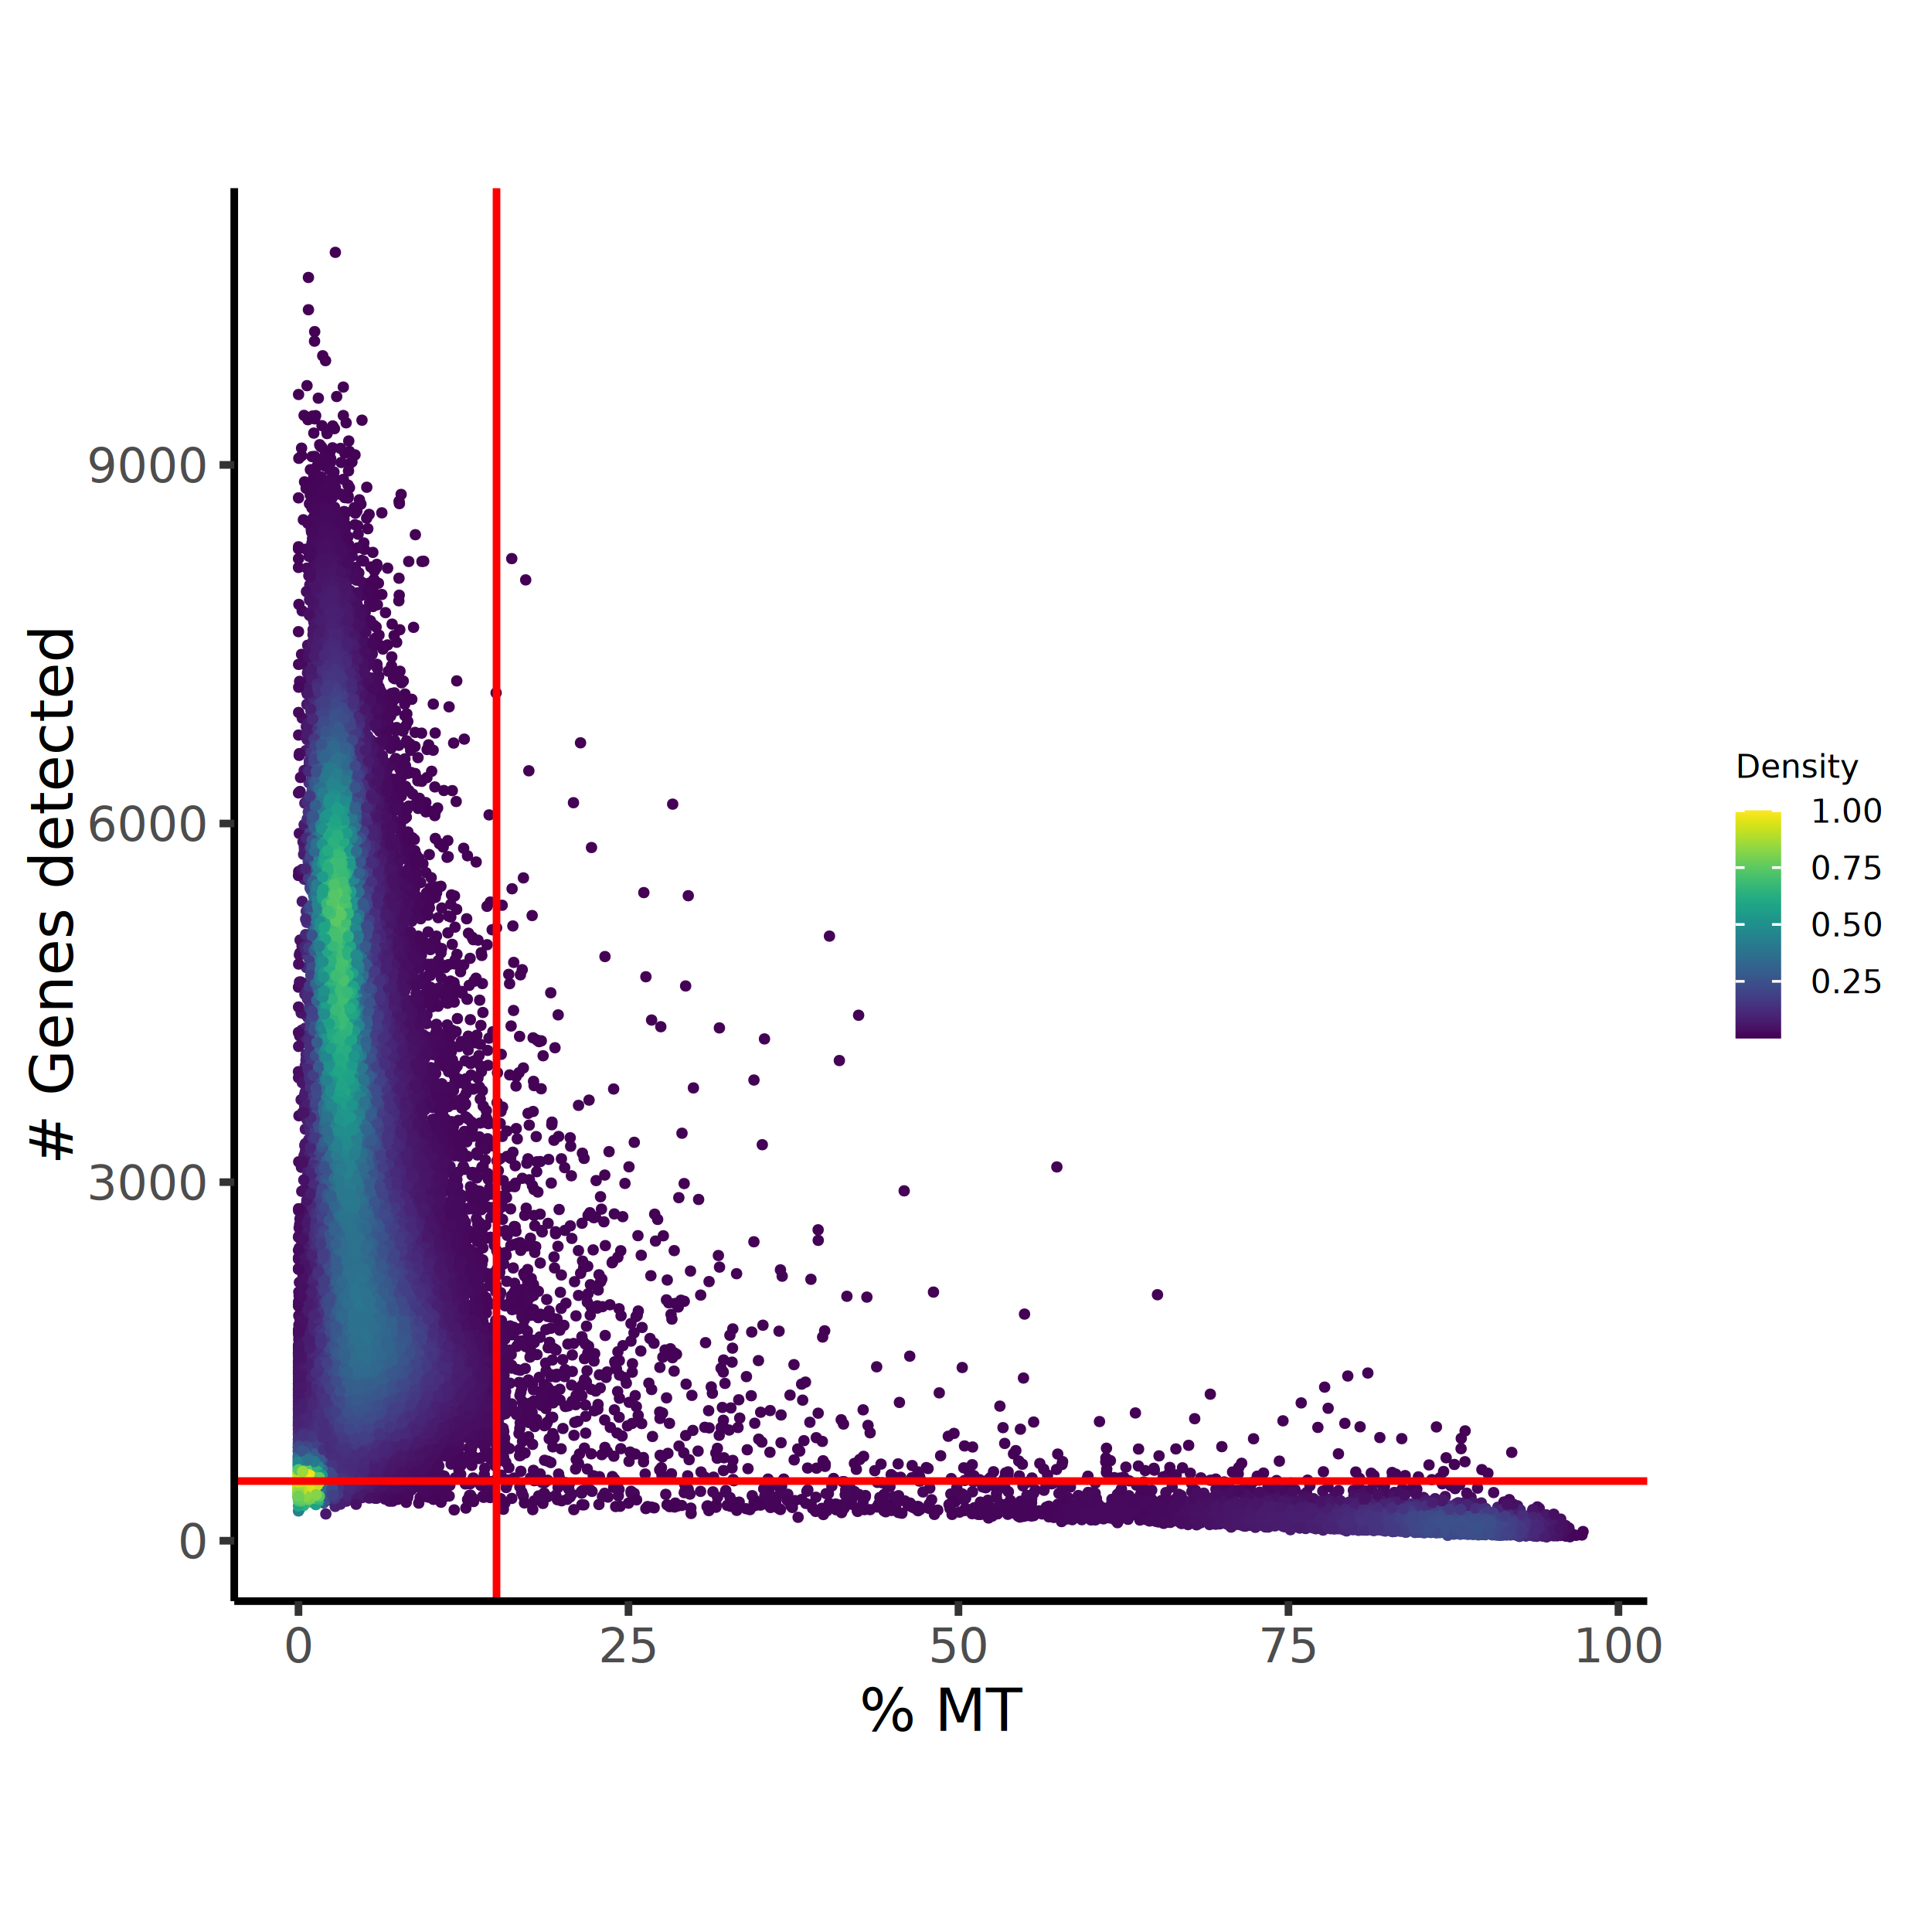

In [11]:
qc_plot +
    geom_hline(yintercept=500, color="red") +
    geom_vline(xintercept=15, color="red")

In [12]:
low_quality_cells <- sapply(all_seurat_objs, function(obj){
    mean(obj$nFeature_RNA < 500 & obj$percent.mt > 15)*100
})

In [13]:
percent_cell_passed_QC <- data.frame(percentage= 100 - low_quality_cells,
                                     sample=sapply(all_seurat_objs, function(obj){
                                         obj$orig.ident[1]
                                     }))

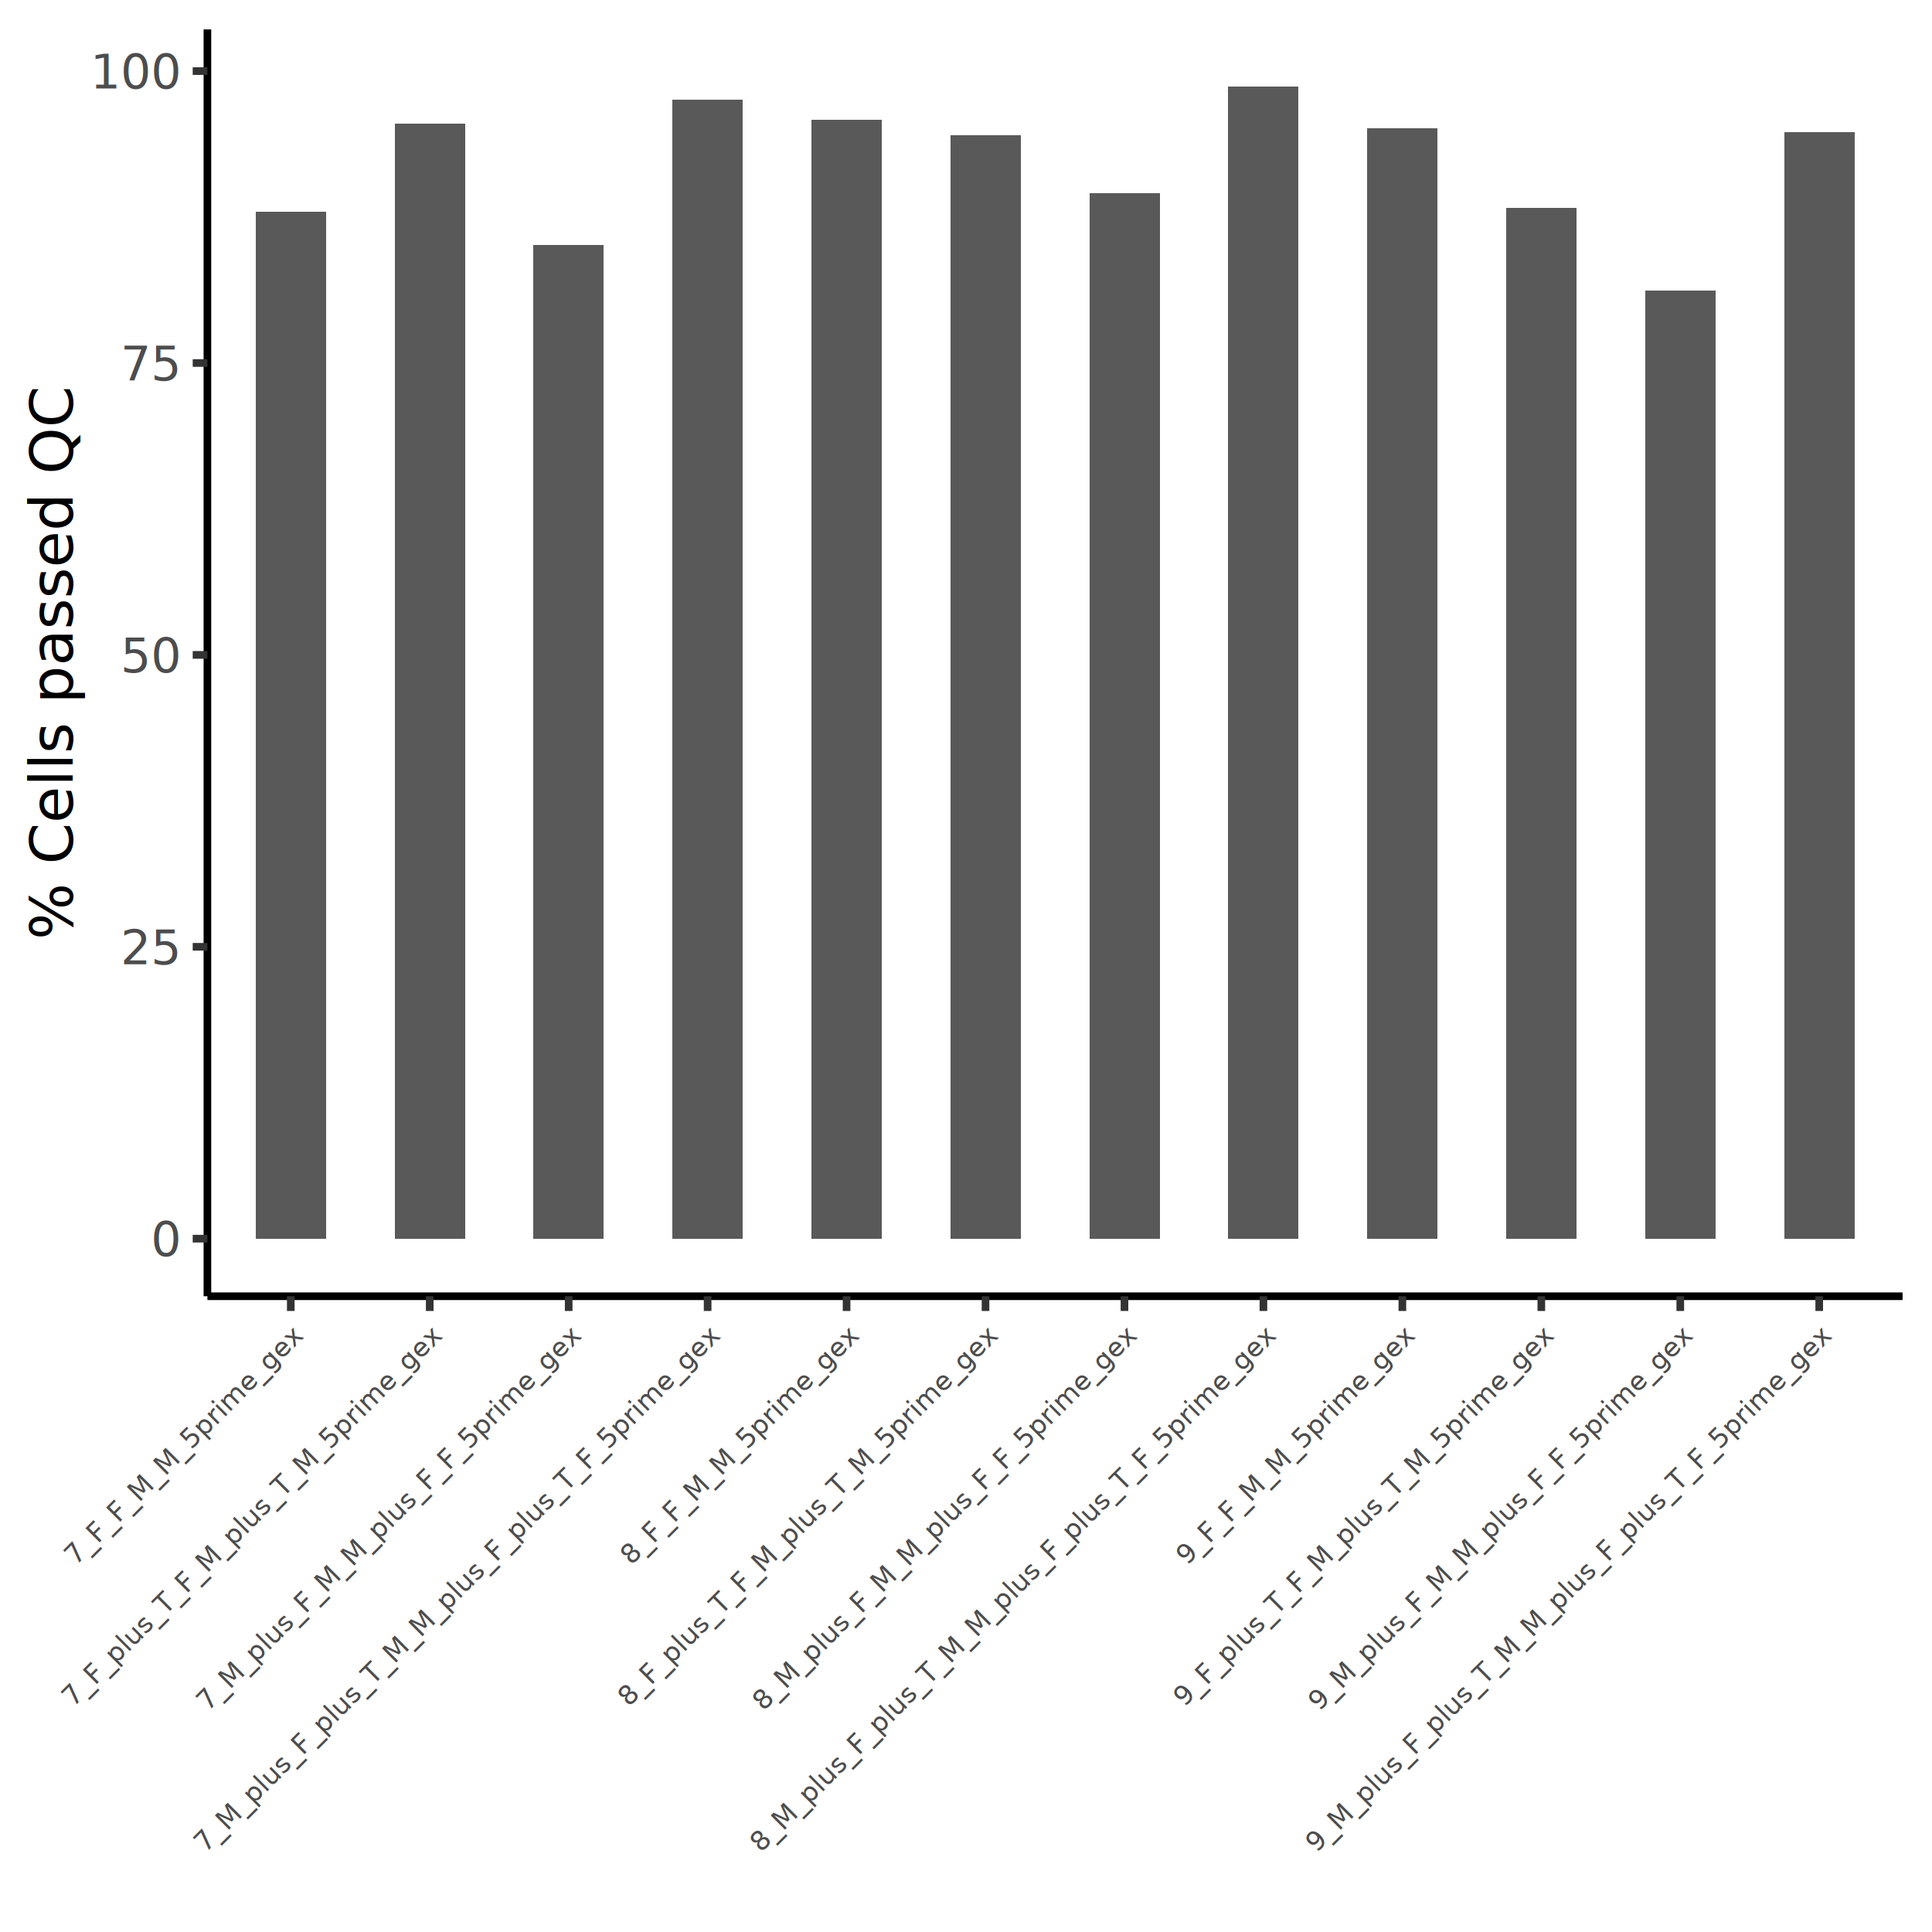

In [14]:
ggplot(percent_cell_passed_QC, aes(sample, percentage)) +
    geom_bar(stat="identity", width=0.5) +
    theme_classic() +
    theme(axis.text.x=element_text(angle=45, hjust=1, size=5)) +
    xlab("") +
    ylab("% Cells passed QC")

In [15]:
all_seurat_objs <- lapply(all_seurat_objs, function(obj){
    obj <- subset(obj, subset=nFeature_RNA > 500 & percent.mt < 15)
    obj
})

In [16]:
all_seurat_objs <- lapply(all_seurat_objs, function(obj){
    identity <- unique(obj$orig.ident)
    message(glue("Processing {identity}"))
    obj <- SCTransform(obj, vars.to.regress="percent.mt", verbose=FALSE)
    obj <- RunPCA(obj, verbose=FALSE)
    obj <- RunUMAP(obj, dims=1:30, verbose=FALSE)
    obj
})

Processing 7_F_F_M_M_5prime_gex

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Processing 7_F_plus_T_F_M_plus_T_M_5prime_gex

Processing 7_M_plus_F_M_M_plus_F_F_5prime_gex

Processing 7_M_plus_F_plu

In [24]:
save_seurat_objs <- lapply(all_seurat_objs, function(obj){
    ident <- obj$orig.ident[1]
    qsave(obj, glue("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/seurat/{ident}.qs"))
})